# Generate trajectory by interpolation

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import plotly.graph_objects as go
import imageio
import base64
import io
from PIL import Image

from utils import MapIntergratedVisualizer, interpolate_closed_curve, smoothen_trajectory

In [163]:
# %pip install nbformat


In [164]:
import pandas as pd

pgm_file = "/home/praks/waypoints/race3.pgm"
origin = [-24.3, -9.81, 0]  # [origin_x, origin_y, rotation]
resolution = 0.05

# Load the file correctly
csv_path = '/home/praks/waypoints/optimals/overtaking.csv'
full_raceline_df = pd.read_csv(csv_path, comment='#', delimiter=';', header=None)

# Set the correct columns
# full_raceline_df.columns = [
#     's_m', 'x_m', 'y_m', 'psi_rad', 'kappa_radpm', 'vx_mps', 'ax_mps2'
# ][:full_raceline_df.shape[1]]

full_raceline_df.columns = [
    'x','y','speed','lookahead'
][:full_raceline_df.shape[1]]

# Extract x, y, and yaw
x = full_raceline_df['x'].to_numpy()
y = full_raceline_df['y'].to_numpy()
# yaw = full_raceline_df['psi_rad'].to_numpy()

# Subsample every 500th point
x = x[::250]
y = y[::250]
# yaw = yaw[::500]

# Initialize the map visualizer
map_viz = MapIntergratedVisualizer(pgm_file, origin, resolution)
fig = map_viz.init_map()

# Plot points
fig = map_viz.add_scatter_points(fig, x=x, y=y)

# Plot yaw arrows
# fig = map_viz.add_yaw_arrows(fig, x=x, y=y, yaw=yaw)


fig.show()
# Show the figure
# fig.show(renderer="browser")

ValueError: Unknown format code 'f' for object of type 'str'

## lookahead management

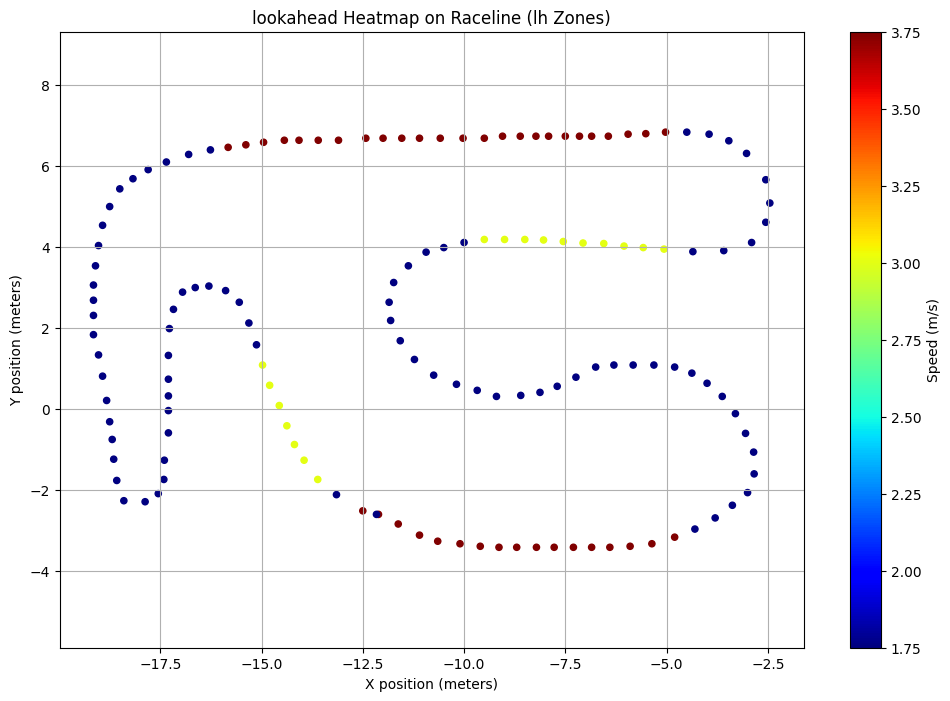

In [ ]:
# === Initialize base lookahead and speed profile ===
lookahead = np.ones_like(x) * 0.7 
speed = np.ones_like(x) * 2.0

# === Define helper function ===
def set_lh(set_lh_arr, speed_arr, start_idx, end_idx, lh_value, speed_value):
    set_lh_arr[start_idx:end_idx] = lh_value
    speed_arr[start_idx:end_idx] = speed_value

# === Apply custom zones ===
set_lh(lookahead, speed, 70, 95, 1.5, 4.5)
set_lh(lookahead, speed, 135, 142, 1.2, 3.5)
set_lh(lookahead, speed, 142, 0, 1.5, 4.0)   # careful here
set_lh(lookahead, speed, 0, 17, 1.5, 4.5)
set_lh(lookahead, speed, 50, 60, 1.2, 3.5)

# === Fix bad range call (146, 0) ===
# When start_idx > end_idx, it doesn't make sense. Let's check and handle:
if 146 > 0:
    set_lh(lookahead, speed, 146, len(lookahead), 1.5, 4.0)
    set_lh(lookahead, speed, 0, 1, 1.5, 4.0)  # Just first index if needed



lookahead = lookahead * 2.5 
speed = speed * 1.5



# === Plot heatmap ===
plt.figure(figsize=(12, 8))

sc = plt.scatter(x, y, c=lookahead, cmap='jet', s=20)
plt.colorbar(sc, label='Speed (m/s)')

plt.xlabel('X position (meters)')
plt.ylabel('Y position (meters)')
plt.title('lookahead Heatmap on Raceline (lh Zones)')
plt.axis('equal')
plt.grid(True)
plt.show()

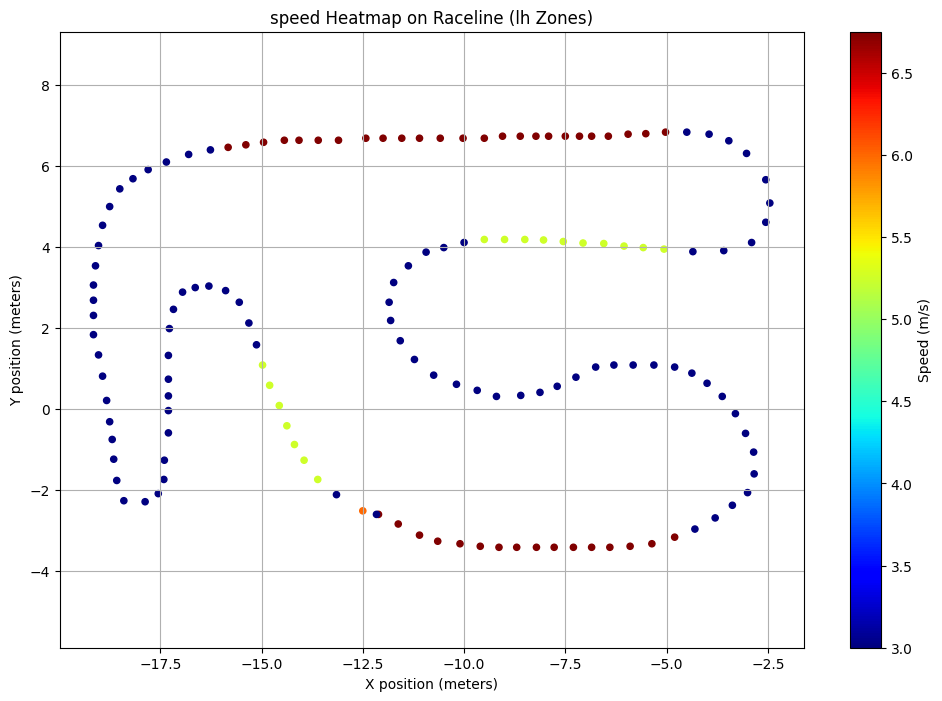

In [ ]:
plt.figure(figsize=(12, 8))

sc = plt.scatter(x, y, c=speed, cmap='jet', s=20)
plt.colorbar(sc, label='Speed (m/s)')

plt.xlabel('X position (meters)')
plt.ylabel('Y position (meters)')
plt.title('speed Heatmap on Raceline (lh Zones)')
plt.axis('equal')
plt.grid(True)
plt.show()

Explicitly reducing speed 

In [ ]:
set_lh(lookahead, speed, 110, 124, 1.0, 2.0)

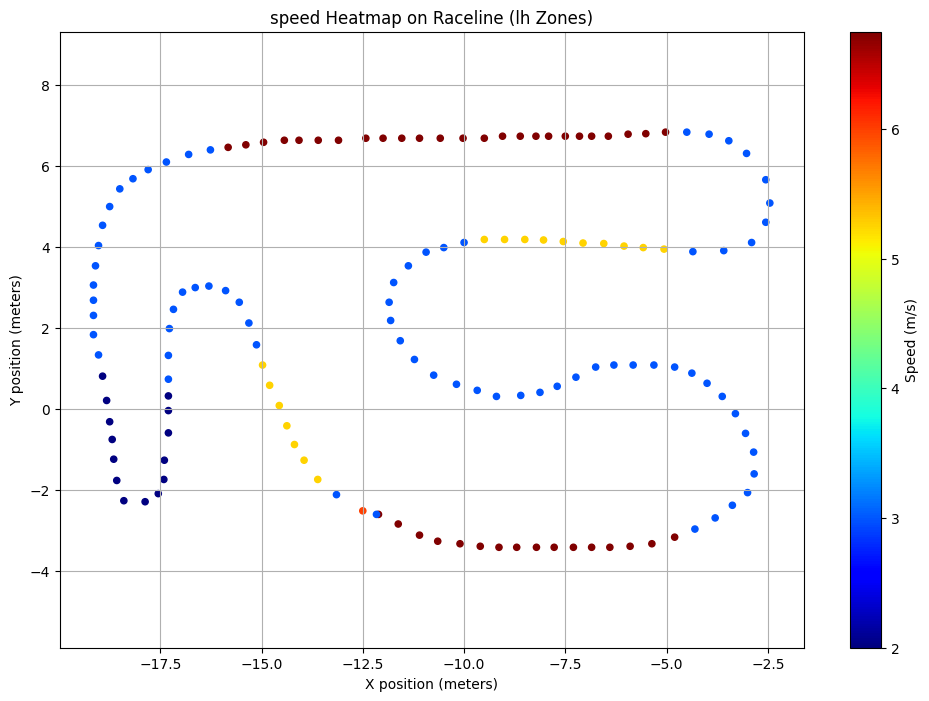

In [ ]:
# # === Initialize base lookahead and speed profile ===
# lookahead = np.ones_like(x) * 0.7
# # speed = np.ones_like(x) * 2.0

# # === Define helper function ===
# def set_lh(set_lh_arr, start_idx, end_idx, lh_value):
#     set_lh_arr[start_idx:end_idx] = lh_value
 

# # === Apply custom zones ===
# set_lh(lookahead, 70, 95, 1.5)
# set_lh(lookahead, 135, 140, 1.2)
# set_lh(lookahead,  146, 0, 1.5)   # careful here
# set_lh(lookahead,  0, 17, 1.5)
# set_lh(lookahead,  50, 60, 1.2)

# # === Fix bad range call (146, 0) ===
# # When start_idx > end_idx, it doesn't make sense. Let's check and handle:
# if 146 > 0:
#     set_lh(lookahead,146, len(lookahead), 1.5)
#     set_lh(lookahead,  0, 1, 1.5)  # Just first index if needed



# # === Plot heatmap ===
plt.figure(figsize=(12, 8))

sc = plt.scatter(x, y, c=speed, cmap='jet', s=20)
plt.colorbar(sc, label='Speed (m/s)')

plt.xlabel('X position (meters)')
plt.ylabel('Y position (meters)')
plt.title('speed Heatmap on Raceline (lh Zones)')
plt.axis('equal')
plt.grid(True)
plt.show()

In [ ]:
# save without speed 

In [ ]:
# x_full = full_raceline_df['x'].to_numpy()
# y_full = full_raceline_df['y'].to_numpy()
# speed_full = full_raceline_df['speed'].to_numpy()

# from scipy.interpolate import interp1d
# # --- Interpolation ---
# # Use arclength as base for interpolation
# arc_full = np.cumsum(np.hstack(([0], np.hypot(np.diff(x_full), np.diff(y_full)))))
# arc_subsampled = np.cumsum(np.hstack(([0], np.hypot(np.diff(x), np.diff(y)))))

# # Interpolating lookahead based on arc-length
# lookahead_interp_fn = interp1d(arc_subsampled, lookahead, kind='nearest', fill_value="extrapolate")
# lookahead_full = lookahead_interp_fn(arc_full)

# # Now, save interpolated dataframe
# interp_df_speed = pd.DataFrame({
#     'x': x_full,
#     'y': y_full,
#     'speed': speed_full,
#     'lookahead': lookahead_full
# })

# # Save to CSV
# interp_df_speed.to_csv('optimal_w_lh.csv', sep=';', index=False)

With speed save

In [ ]:
# speed = np.mean(speed)
# print(speed)

In [ ]:
# Extract full data
x_full = full_raceline_df['x'].to_numpy()
y_full = full_raceline_df['y'].to_numpy()


# === Interpolation based on arc-length ===
from scipy.interpolate import interp1d

arc_full = np.cumsum(np.hstack(([0], np.hypot(np.diff(x_full), np.diff(y_full)))))
arc_subsampled = np.cumsum(np.hstack(([0], np.hypot(np.diff(x), np.diff(y)))))

# Interpolators
lookahead_interp_fn = interp1d(arc_subsampled, lookahead, kind='nearest', fill_value="extrapolate")
speed_interp_fn = interp1d(arc_subsampled, speed, kind='nearest', fill_value="extrapolate")

# Interpolate to full centerline
lookahead_full = lookahead_interp_fn(arc_full)
speed_full = speed_interp_fn(arc_full)

# === Save to CSV ===
interp_df_speed = pd.DataFrame({
    'x': x_full,
    'y': y_full,
    'speed': speed_full,
    'lookahead': lookahead_full
})

interp_df_speed.to_csv('optimals/overtaking.csv', sep=';', index=False)